In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [2]:
X = load_diabetes().data
y = load_diabetes().target

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [4]:
X_temp = load_diabetes()
X_temp.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
import numpy as np

class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, epochs=1000, batch_size=None):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.theta = None

    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.zeros(n + 1)
        X = np.c_[np.ones(m), X]
        
        if self.batch_size is None or self.batch_size > m:
            self.batch_size = m 
        
        cost_history = []
        
        for epoch in range(self.epochs):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            for i in range(0, m, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]
                
                y_pred = X_batch.dot(self.theta) 
                error = y_pred - y_batch
                
                gradients = (2 / self.batch_size) * X_batch.T.dot(error)
                
                self.theta -= self.learning_rate * gradients
            
            y_pred_full = X.dot(self.theta)
            cost = np.mean((y_pred_full - y) ** 2)
            cost_history.append(cost)
            
            if epoch % 100 == 0:
                print(f'Epoch {epoch}: Cost = {cost:.4f}')
        
        return cost_history

    def predict(self, X):
        m = X.shape[0]
        X = np.c_[np.ones(m), X]
        return X.dot(self.theta)


In [7]:
batch_gd = LinearRegressionGD(learning_rate=0.01, epochs=2000, batch_size=None)
sgd = LinearRegressionGD(learning_rate=0.01, epochs=2000, batch_size=1)
mini_batch_gd = LinearRegressionGD(learning_rate=0.01, epochs=2000, batch_size=16)

In [8]:
cost_batch = batch_gd.fit(X_train, y_train)
cost_sgd = sgd.fit(X_train, y_train)
cost_mini = mini_batch_gd.fit(X_train, y_train)

Epoch 0: Cost = 28359.3405
Epoch 100: Cost = 3298.4984
Epoch 200: Cost = 2906.0677
Epoch 300: Cost = 2896.9731
Epoch 400: Cost = 2895.6922
Epoch 500: Cost = 2894.6868
Epoch 600: Cost = 2893.7324
Epoch 700: Cost = 2892.8149
Epoch 800: Cost = 2891.9316
Epoch 900: Cost = 2891.0809
Epoch 1000: Cost = 2890.2616
Epoch 1100: Cost = 2889.4724
Epoch 1200: Cost = 2888.7120
Epoch 1300: Cost = 2887.9794
Epoch 1400: Cost = 2887.2736
Epoch 1500: Cost = 2886.5935
Epoch 1600: Cost = 2885.9381
Epoch 1700: Cost = 2885.3066
Epoch 1800: Cost = 2884.6980
Epoch 1900: Cost = 2884.1116
Epoch 0: Cost = 3234.9550
Epoch 100: Cost = 3334.3611
Epoch 200: Cost = 2952.3586
Epoch 300: Cost = 3116.2801
Epoch 400: Cost = 3052.8604
Epoch 500: Cost = 3009.1741
Epoch 600: Cost = 3252.8187
Epoch 700: Cost = 3096.0513
Epoch 800: Cost = 3381.7935
Epoch 900: Cost = 3005.5510
Epoch 1000: Cost = 3281.4751
Epoch 1100: Cost = 3068.3339
Epoch 1200: Cost = 3064.1437
Epoch 1300: Cost = 3316.2961
Epoch 1400: Cost = 2981.6430
Epoch 15

In [9]:
sgd_predictions = sgd.predict(X_test)
batch_predictions = batch_gd.predict(X_test)
mini_batch_predictions = mini_batch_gd.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, batch_predictions)
mae = mean_absolute_error(y_test, batch_predictions)
r2 = r2_score(y_test, batch_predictions)

print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, R² Score: {r2:.4f}")

mse = mean_squared_error(y_test, sgd_predictions)
mae = mean_absolute_error(y_test, sgd_predictions)
r2 = r2_score(y_test, sgd_predictions)

print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, R² Score: {r2:.4f}")

mse = mean_squared_error(y_test, mini_batch_predictions)
mae = mean_absolute_error(y_test, mini_batch_predictions)
r2 = r2_score(y_test, mini_batch_predictions)

print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, R² Score: {r2:.4f}")


MSE: 2886.5293, MAE: 42.8527, R² Score: 0.4552
MSE: 3332.2494, MAE: 45.9012, R² Score: 0.3711
MSE: 2901.5120, MAE: 42.8527, R² Score: 0.4524


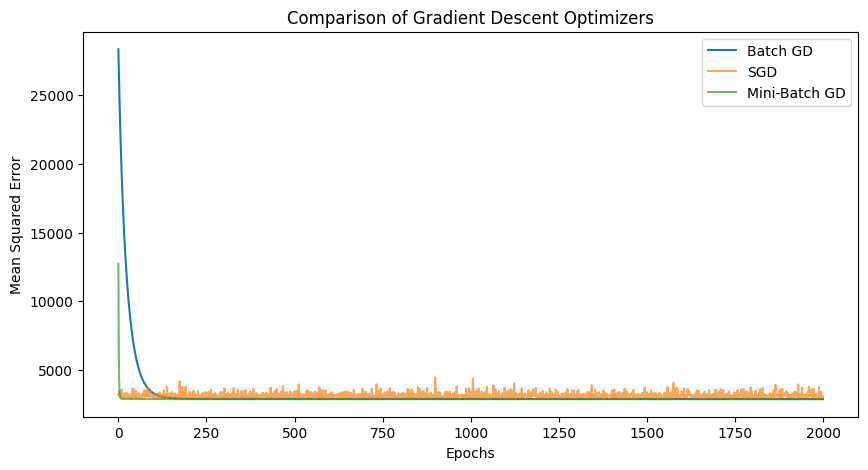

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(cost_batch, label='Batch GD')
plt.plot(cost_sgd, label='SGD', alpha=0.7)
plt.plot(cost_mini, label='Mini-Batch GD', alpha=0.7)
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of Gradient Descent Optimizers")
plt.legend()
plt.show()

In [43]:
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [44]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, R² Score: {r2:.4f}")

MSE: 2900.1936, MAE: 42.7941, R² Score: 0.4526
